<a href="https://colab.research.google.com/github/MaximeG2110/2026_Intro_Python/blob/main/live/part-I/1.5-pandas-environmental-exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> Notebook-friendly copy of `part-I/1.5-pandas-environmental-exercises.ipynb`, generated by `tools/make_live.py`. Edit the book notebook, not this file.

In [1]:
# --- environment setup (generated, not part of the lesson) ---
# Colab and Kaggle do not ship every package this notebook imports.
# This is a no-op in an environment that is already set up.
import importlib.util
import subprocess
import sys

for module, package in {"pooch": "pooch"}.items():
    if importlib.util.find_spec(module) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", package], check=True)

# Environmental Exercises

**ℹ️ How to use these exercises**

Attempt each from scratch in the empty code cell. Import pandas as `pd` and numpy as `np`, seed any randomness with `default_rng`, and keep units in your column names.

## Exercise 1: Earthquake data analysis

<img src="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/part-I/_static/usgs-2014-south-napa-earthquake.jpg" alt="A dirt track through a vineyard, broken along its length by a continuous ridge of pushed-up soil following the fault trace" width="800">

<em>Surface rupture from the magnitude 6.0 South Napa earthquake of 24 August 2014 — the kind of event a row in this catalog stands for. The continuous "mole track" running parallel to the strike of the fault indicates some east–west compression on top of the <a href="https://www.usgs.gov/faqs/what-fault-and-what-are-different-types">right-lateral faulting</a>; taken near Buhman Road. Photo <a href="https://www.usgs.gov/media/images/2014-south-napa-ca-m6-earthquake-august-24-6">USGS</a>, public domain.</em>


This exercise reviews the `pandas` fundamentals of this subchapter on one real catalog, covering how to

* open csv files
* manipulate dataframe indexes
* parse date columns
* examine basic dataframe statistics
* manipulate text columns and extract values
* plot dataframe contents using
  * bar charts
  * histograms
  * scatter plots

The data is a snapshot of the [USGS Earthquakes Database](https://earthquake.usgs.gov/earthquakes/search/): every event recorded worldwide in 2014, 120 108 rows.

You do not need to download the file yourself. The pre-supplied cell below fetches and caches it with the help of [pooch](https://www.fatiando.org/pooch/latest/) — there is no need to read pooch's documentation unless you want to — and stores the path to the file in the variable `datafile`.

In [2]:
# Pre-supplied: download and cache the earthquake data.
import pooch

datafile = pooch.retrieve(
    url="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/data/part-I/usgs_earthquakes_2014.csv",
    known_hash="sha256:84d455fb96dc8f782fba4b5fbe56cb8970cab678f07c766fcba1b1c4674de1b1",
    fname="usgs_earthquakes_2014.csv",
    path=pooch.os_cache("mlees"),
)

**ℹ️ Beyond this subchapter**

The tools below were not demonstrated in 1.5's lecture. Each question links its documentation where
it is needed; they are collected here so you know when you are being asked to read a new page rather
than to recall one:

- [`nlargest`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.nlargest.html) — Q5
- [pandas' text data functions](https://pandas.pydata.org/pandas-docs/stable/user_guide/text.html), and [`Series.str.split`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.str.split.html) in particular — Q6
- [`unique`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.unique.html) — Q7
- [`count`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.count.html) and [`value_counts`](https://pandas.pydata.org/docs/reference/api/pandas.Series.value_counts.html) — Q9

The scatter plot and colorbar in Q11 are the ones from 1.4.6. Everything else the questions ask for
is from this subchapter's lecture: `read_csv` with date-parsed columns, `set_index`, `.head()`,
`.info()`, `.describe()`, boolean filtering, `.index` and `.values`, `kind="bar"`, `kind="hist"`, and
a logarithmic count axis.

**Q1) First, import `numpy`, `pandas` and `matplotlib`, and — optionally — set the display options.**

Hint: display options are documented [at this link](https://pandas.pydata.org/pandas-docs/stable/user_guide/options.html).

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


**Q2) Use pandas' `read_csv` function directly on `datafile` to open it as a `DataFrame`.**

Display the first few rows with `.head()`, and the column names, dtypes and non-null counts with
`.info()`. Check these tutorials if you have doubts about what the two functions do:
[`.head()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.head.html)
and
[`.info()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.info.html?highlight=info#pandas.DataFrame.info).

`.info()` will show you that the two date columns, `time` and `updated`, came in as plain strings
rather than as dates. They were not parsed automatically. What can you do about that?

In [4]:
# Open the file as a pandas DataFrame, then display the first few rows and the DataFrame info
df = pd.read_csv(datafile)
df

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,id,updated,place,type
0,2014-01-31 23:53:37.000,60.252000,-152.708100,90.20,1.10,ml,NaN,NaN,NaN,0.2900,ak,ak11155107,2014-02-05T19:34:41.515Z,"26km S of Redoubt Volcano, Alaska",earthquake
1,2014-01-31 23:48:35.452,37.070300,-115.130900,0.00,1.33,ml,4.0,171.43,0.342000,0.0247,nn,nn00436847,2014-02-01T01:35:09.000Z,"32km S of Alamo, Nevada",earthquake
2,2014-01-31 23:47:24.000,64.671700,-149.252800,7.10,1.30,ml,NaN,NaN,NaN,1.0000,ak,ak11151142,2014-02-01T00:03:53.010Z,"12km NNW of North Nenana, Alaska",earthquake
3,2014-01-31 23:30:54.000,63.188700,-148.957500,96.50,0.80,ml,NaN,NaN,NaN,1.0700,ak,ak11151135,2014-01-31T23:41:25.007Z,"22km S of Cantwell, Alaska",earthquake
4,2014-01-31 23:30:52.210,32.616833,-115.692500,10.59,1.34,ml,6.0,285.00,0.043210,0.2000,ci,ci37171541,2014-02-01T00:13:20.107Z,"10km WNW of Progreso, Mexico",earthquake
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120103,2014-12-01 00:10:16.000,60.963900,-146.762900,14.80,3.80,ml,NaN,NaN,NaN,0.6900,ak,ak11453391,2015-03-24T18:25:07.628Z,"29km SW of Valdez, Alaska",earthquake
120104,2014-12-01 00:09:39.000,58.869100,-154.415900,108.40,2.40,ml,NaN,NaN,NaN,0.6700,ak,ak11453395,2014-12-10T01:04:25.209Z,"102km SSE of Old Iliamna, Alaska",earthquake
120105,2014-12-01 00:09:25.350,38.843498,-122.825836,2.37,0.43,md,8.0,107.00,0.008991,0.0300,nc,nc72358451,2014-12-01T01:15:02.814Z,"9km WNW of Cobb, California",earthquake
120106,2014-12-01 00:05:54.000,65.152100,-148.992000,9.50,0.40,ml,NaN,NaN,NaN,0.6900,ak,ak11453390,2014-12-10T01:03:01.225Z,"57km NW of Ester, Alaska",earthquake


**Q3) Re-read the data in such a way that both date columns are identified as dates and the earthquake ID is used as the index.**

Check with `.head()` and `.info()` that it worked: `time` and `updated` should now be
`datetime64` columns, and `id` should be the index rather than a column.

Hint: the documentation for `read_csv` is [here](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html?highlight=read_csv).

In [5]:
# Re-read the file, then check with head and info that it worked
df.set_index("id")
df['time'] = pd.to_datetime(df['time'])
df['updated'] = pd.to_datetime(df['updated'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120108 entries, 0 to 120107
Data columns (total 15 columns):
 #   Column     Non-Null Count   Dtype              
---  ------     --------------   -----              
 0   time       120108 non-null  datetime64[ns]     
 1   latitude   120108 non-null  float64            
 2   longitude  120108 non-null  float64            
 3   depth      120107 non-null  float64            
 4   mag        120065 non-null  float64            
 5   magType    120065 non-null  object             
 6   nst        59688 non-null   float64            
 7   gap        94935 non-null   float64            
 8   dmin       85682 non-null   float64            
 9   rms        119716 non-null  float64            
 10  net        120108 non-null  object             
 11  id         120108 non-null  object             
 12  updated    120108 non-null  datetime64[ns, UTC]
 13  place      120108 non-null  object             
 14  type       120108 non-null  object  

**Q4) Use `describe` to get the basic statistics of all the columns.**

Hint: the documentation of `describe` is [at this link](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html).

In [6]:
pd.DataFrame.describe(df)

,time,latitude,longitude,depth,mag,nst,gap,dmin,rms
count,120108,120108.000000,120108.000000,120107.000000,120065.000000,59688.000000,94935.000000,85682.000000,119716.000000
mean,2014-07-05 09:10:37.116720128,38.399579,-99.961402,28.375029,1.793958,17.878284,124.048978,0.893198,0.358174
min,2014-01-01 00:01:16.610000,-73.462000,-179.998900,-9.900000,-0.970000,0.000000,9.000000,0.000000,0.000000
25%,2014-04-08 03:43:10.768999936,34.228917,-147.742025,4.100000,0.820000,8.000000,74.000000,0.020760,0.070000
50%,2014-07-07 10:44:06.035000064,38.805300,-120.832000,9.200000,1.400000,14.000000,107.000000,0.073670,0.200000
75%,2014-09-30 23:36:40.595000064,53.889500,-116.068100,22.880000,2.400000,22.000000,155.000000,0.447000,0.590000
max,2014-12-31 23:54:33.900000,86.651400,179.998000,697.360000,8.200000,365.000000,356.400000,64.498000,8.460000
std,NaN,21.938258,82.996858,62.215416,1.343466,14.911369,68.518595,2.903966,0.364046


**Q5) Use `nlargest` to get the top 20 earthquakes by magnitude.**

Hint: the documentation of `nlargest` is [at this link](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.nlargest.html).

In [7]:
pd.DataFrame.nlargest(df, 20, 'mag', keep='last')

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,id,updated,place,type
37371,2014-04-01 23:46:47.260,-19.6097,-70.7691,25.00,8.2,mww,NaN,23.0,0.609,0.66,us,usc000nzvd,2015-07-30 16:24:51.223000+00:00,"94km NW of Iquique, Chile",earthquake
50562,2014-06-23 20:53:09.700,51.8486,178.7352,109.00,7.9,mww,NaN,22.0,0.133,0.71,us,usc000rki5,2015-04-18 21:54:08.699000+00:00,"19km SE of Little Sitkin Island, Alaska",earthquake
36918,2014-04-03 02:43:13.110,-20.5709,-70.4931,22.40,7.7,mww,NaN,44.0,1.029,0.82,us,usc000p27i,2015-06-06 07:31:05.755000+00:00,"53km SW of Iquique, Chile",earthquake
33808,2014-04-12 20:14:39.300,-11.2701,162.1481,22.56,7.6,mww,NaN,13.0,2.828,0.71,us,usc000phx5,2015-04-18 21:54:27.398000+00:00,"93km SSE of Kirakira, Solomon Islands",earthquake
31496,2014-04-19 13:28:00.810,-6.7547,155.0241,43.37,7.5,mww,NaN,16.0,3.820,1.25,us,usb000pr89,2015-04-18 21:54:18.633000+00:00,"70km SW of Panguna, Papua New Guinea",earthquake
33537,2014-04-13 12:36:19.230,-11.4633,162.0511,39.00,7.4,mww,NaN,17.0,2.885,1.00,us,usc000piqj,2015-08-13 19:29:13.018000+00:00,"112km S of Kirakira, Solomon Islands",earthquake
95913,2014-10-14 03:51:34.460,12.5262,-88.1225,40.00,7.3,mww,NaN,18.0,1.078,0.70,us,usb000slwn,2015-08-13 19:35:02.679000+00:00,"74km S of Intipuca, El Salvador",earthquake
31850,2014-04-18 14:27:24.920,17.3970,-100.9723,24.00,7.2,mww,NaN,46.0,2.250,1.20,us,usb000pq41,2015-08-13 19:30:39.599000+00:00,"33km ESE of Petatlan, Mexico",earthquake
111052,2014-11-01 18:57:22.380,-19.6903,-177.7587,434.00,7.1,mww,NaN,13.0,4.415,0.84,us,usc000stdc,2015-01-20 09:03:09.040000+00:00,"144km NE of Ndoi Island, Fiji",earthquake
106285,2014-11-15 02:31:41.720,1.8929,126.5217,45.00,7.1,mww,NaN,18.0,1.397,0.71,us,usc000sxh8,2015-03-20 18:42:02.735000+00:00,"154km NW of Kota Ternate, Indonesia",earthquake


**Q6) Extract the state or country using pandas' text data functions, and add it as a new column to the `DataFrame`.**

Examine the column titled `place`: it holds strings like `"26km S of Redoubt Volcano, Alaska"`, so
it carries both the local description and the state or country. Pull the second part out and store
it in a new column called `country`.

Hint 1: the documentation for pandas' text data functions is [here](https://pandas.pydata.org/pandas-docs/stable/text.html).

Hint 2: you will use `.split()` to extract the country names. The documentation of this function
can be found [here](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.str.split.html?highlight=split#pandas.Series.str.split).

In [8]:
df["country"] = df["place"].str.split(",").str[-1].str.strip()
df

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,id,updated,place,type,country
0,2014-01-31 23:53:37.000,60.252000,-152.708100,90.20,1.10,ml,NaN,NaN,NaN,0.2900,ak,ak11155107,2014-02-05 19:34:41.515000+00:00,"26km S of Redoubt Volcano, Alaska",earthquake,Alaska
1,2014-01-31 23:48:35.452,37.070300,-115.130900,0.00,1.33,ml,4.0,171.43,0.342000,0.0247,nn,nn00436847,2014-02-01 01:35:09+00:00,"32km S of Alamo, Nevada",earthquake,Nevada
2,2014-01-31 23:47:24.000,64.671700,-149.252800,7.10,1.30,ml,NaN,NaN,NaN,1.0000,ak,ak11151142,2014-02-01 00:03:53.010000+00:00,"12km NNW of North Nenana, Alaska",earthquake,Alaska
3,2014-01-31 23:30:54.000,63.188700,-148.957500,96.50,0.80,ml,NaN,NaN,NaN,1.0700,ak,ak11151135,2014-01-31 23:41:25.007000+00:00,"22km S of Cantwell, Alaska",earthquake,Alaska
4,2014-01-31 23:30:52.210,32.616833,-115.692500,10.59,1.34,ml,6.0,285.00,0.043210,0.2000,ci,ci37171541,2014-02-01 00:13:20.107000+00:00,"10km WNW of Progreso, Mexico",earthquake,Mexico
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120103,2014-12-01 00:10:16.000,60.963900,-146.762900,14.80,3.80,ml,NaN,NaN,NaN,0.6900,ak,ak11453391,2015-03-24 18:25:07.628000+00:00,"29km SW of Valdez, Alaska",earthquake,Alaska
120104,2014-12-01 00:09:39.000,58.869100,-154.415900,108.40,2.40,ml,NaN,NaN,NaN,0.6700,ak,ak11453395,2014-12-10 01:04:25.209000+00:00,"102km SSE of Old Iliamna, Alaska",earthquake,Alaska
120105,2014-12-01 00:09:25.350,38.843498,-122.825836,2.37,0.43,md,8.0,107.00,0.008991,0.0300,nc,nc72358451,2014-12-01 01:15:02.814000+00:00,"9km WNW of Cobb, California",earthquake,California
120106,2014-12-01 00:05:54.000,65.152100,-148.992000,9.50,0.40,ml,NaN,NaN,NaN,0.6900,ak,ak11453390,2014-12-10 01:03:01.225000+00:00,"57km NW of Ester, Alaska",earthquake,Alaska


**Q7) Display each unique value from the new `country` column.**

Hint: you may use the `unique` function documented [at this link](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.unique.html).

You should see an array of a couple of hundred country and state names. A plain split leaves the
space that followed the comma, so they come out as `array([' Alaska', ' Nevada', ...])` — worth
removing before you use them as labels.

In [9]:
uniques = pd.Series.unique(df['country'])
print(uniques)
print(uniques.shape)

['Alaska' 'Nevada' 'Mexico' 'California' 'Papua New Guinea' 'New Zealand'
 'Missouri' 'South of the Fiji Islands' 'Montana' 'British Virgin Islands'
 'Washington' 'Oregon' 'Canada' 'Fiji' 'Wyoming' 'Antarctica' 'Chile'
 'Utah' 'Indonesia' 'Solomon Islands' 'Micronesia' 'Oklahoma' 'Hawaii'
 'Russia' 'Arizona' 'Philippines' 'Bolivia' 'Greece' 'Japan' 'Puerto Rico'
 'Iran' 'Tonga' 'Wallis and Futuna' 'Colorado' 'Guam' 'CA'
 'Carlsberg Ridge' 'Idaho' 'Pakistan'
 'Off the west coast of northern Sumatra' 'Burma' 'China' 'Peru'
 'Off the east coast of the North Island of New Zealand' 'Costa Rica'
 'Reykjanes Ridge' 'East Timor' 'Central East Pacific Rise'
 'Mid-Indian Ridge' 'Japan region' 'Northern Mariana Islands'
 'El Salvador' 'Samoa' 'Northern Mid-Atlantic Ridge' 'Taiwan' 'Arkansas'
 'South Sandwich Islands' 'Colombia' 'Dominican Republic' 'Argentina'
 'Texas' 'New Hampshire' 'Saint Helena' 'West of Vancouver Island'
 'Tanzania' 'Vanuatu' 'Bosnia and Herzegovina' 'India' 'American Samoa'

**Q8) Create a filtered dataset that only has earthquakes larger than magnitude 4.**

Hint: print the table to see the name of the column containing the earthquake magnitude.

Check out this [link](https://www.geeksforgeeks.org/ways-to-filter-pandas-dataframe-by-column-values/)
to find examples of filtering by column values.

In [10]:
# Filter the dataset based on the earthquakes' magnitudes
df_mag4 = df[df["mag"] > 4]
df_mag4

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,id,updated,place,type,country
10,2014-01-31 23:08:03.660,-4.9758,153.9466,110.18,4.2,mb,NaN,98.0,1.940,0.61,us,usc000mqlp,2014-04-08 01:43:19+00:00,"115km ESE of Taron, Papua New Guinea",earthquake,Papua New Guinea
14,2014-01-31 22:54:32.970,-28.1775,-177.9058,95.84,4.3,mb,NaN,104.0,1.063,1.14,us,usc000mqln,2014-04-08 01:43:19+00:00,"120km N of Raoul Island, New Zealand",earthquake,New Zealand
16,2014-01-31 22:49:49.740,-23.1192,179.1174,528.34,4.4,mb,NaN,80.0,5.439,0.95,us,usc000mqls,2014-04-08 01:43:19+00:00,South of the Fiji Islands,earthquake,South of the Fiji Islands
26,2014-01-31 22:19:44.330,51.1569,-178.0910,37.50,4.2,mb,NaN,NaN,NaN,0.83,us,usc000mf1x,2014-04-08 01:43:19+00:00,"72km E of Amatignak Island, Alaska",earthquake,Alaska
31,2014-01-31 21:56:44.320,-4.8800,153.8434,112.66,4.3,mb,NaN,199.0,1.808,0.79,us,usc000mqlm,2014-04-08 01:43:19+00:00,"100km ESE of Taron, Papua New Guinea",earthquake,Papua New Guinea
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120064,2014-12-01 02:56:07.950,21.2031,143.5484,11.05,4.4,mb,NaN,107.0,5.996,0.87,us,usc000t6yh,2015-02-24 00:35:14.040000+00:00,"158km WNW of Farallon de Pajaros, Northern Mar...",earthquake,Northern Mariana Islands
120077,2014-12-01 01:50:23.380,-7.8798,106.4275,52.10,4.3,mb,NaN,119.0,1.412,1.50,us,usc000t6y2,2015-02-24 00:35:14.040000+00:00,"57km SSW of Cibungur, Indonesia",earthquake,Indonesia
120090,2014-12-01 01:04:17.890,7.1429,126.8844,176.67,4.3,mb,NaN,134.0,1.297,0.87,us,usc000t6y1,2015-02-24 00:35:14.040000+00:00,"37km ESE of Santiago, Philippines",earthquake,Philippines
120098,2014-12-01 00:40:02.720,37.2096,71.9458,95.57,4.2,mb,NaN,125.0,1.097,0.91,us,usb000t1gp,2015-02-24 00:35:14.040000+00:00,"11km ESE of Roshtqal'a, Tajikistan",earthquake,Tajikistan


**Q9) Using the filtered dataset (magnitude > 4), count the number of earthquakes whose magnitudes are above 4 [Num 1], and count the number of earthquakes in each country or state [Num 2]. Make a bar chart of Num 2 for the top 5 locations with the most earthquakes.**

Hint 1: to get Num 1, pandas has a `count` function documented
[at this link](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.count.html).

Hint 2: check out the
[`value_counts`](https://pandas.pydata.org/docs/reference/api/pandas.Series.value_counts.html)
function to get Num 2.

Then convert the first five rows of Num 2 into a `DataFrame` with two columns, `country` (text)
and `earthquake_num` (number), and recreate the bar chart below.

<img src="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/part-I/_static/1.5-target-top5-bar.png" alt="A bar chart of the number of magnitude-above-4 earthquakes in the five countries with the most of them" width="700">

<em>The five locations with the most magnitude-above-4 events in 2014.</em>

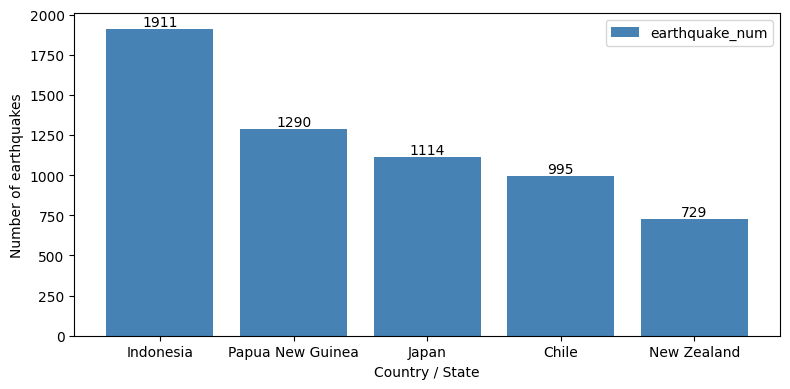

In [23]:
# Count the >4 earthquakes, count them per country, then plot the top 5 as a bar chart
pd.DataFrame.count(df_mag4)
df_country = df_mag4["country"].value_counts()

top5 = df_country.head(5).reset_index()
top5.columns = ["country", "earthquake_num"]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(top5["country"], top5["earthquake_num"], color="steelblue")

ax.set_xlabel("Country / State")
ax.set_ylabel("Number of earthquakes")
ax.bar_label(bars)  # show the count above each bar
ax.legend(["earthquake_num"])

plt.tight_layout()
plt.show()

**Q10) Make a histogram for the distribution of the earthquakes' magnitudes.**

Hint: pandas has a histogram function documented
[at this link](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.hist.html) and
matplotlib has one documented
[at this link](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.hist.html).

<img src="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/part-I/_static/1.5-target-magnitude-hist.png" alt="A histogram of earthquake magnitude with a dashed grid" width="700">

<em>The distribution of magnitude across the whole catalog.</em>


Then redraw it with a logarithmic scale on the y-axis, which brings the rare large events into
view alongside the many small ones. Hint: here you can find a
[tutorial](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.yscale.html) for how to
change an axis scale.

<img src="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/part-I/_static/1.5-target-magnitude-hist-log.png" alt="The same histogram of earthquake magnitude with a logarithmic y-axis" width="700">

<em>The same histogram with a logarithmic count axis.</em>


Finally, make one histogram for the filtered dataset and one for the unfiltered dataset, side by
side.

<img src="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/part-I/_static/1.5-target-hist-filtered-unfiltered.png" alt="Two histograms of earthquake magnitude side by side, one for events above magnitude 4 and one for the whole catalog" width="100%">

<em>The filtered and unfiltered magnitude distributions, drawn on their own count axes.</em>

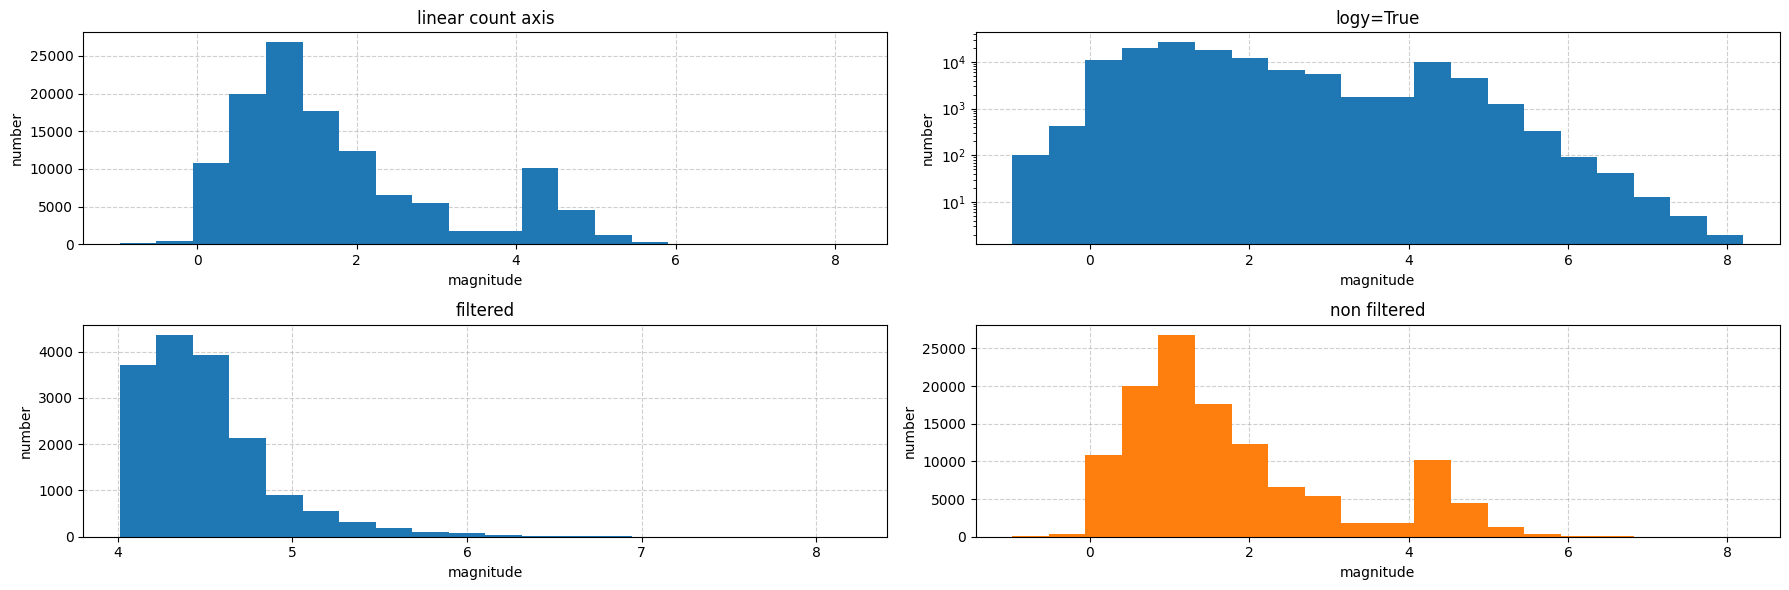

In [47]:
fig, ax = plt.subplots(2, 2, figsize=(18, 6))

df["mag"].plot(ax=ax[0,0], kind="hist", bins=20, color="tab:blue")
ax[0,0].set_title("linear count axis")

df["mag"].plot(ax=ax[0,1], kind="hist", bins=20, color="tab:blue", logy=True)
ax[0,1].set_title("logy=True")

df_mag4["mag"].plot(ax=ax[1,0], kind="hist", bins=20, color="tab:blue")
ax[1,0].set_title("filtered")

df["mag"].plot(ax=ax[1,1], kind="hist", bins=20, color="tab:orange")
ax[1,1].set_title("non filtered")

for axis in ax.flat:
    axis.set_xlabel("magnitude")
    axis.set_ylabel("number")
    axis.grid(alpha=0.6, linestyle="--")
    axis.set_axisbelow(True)
plt.tight_layout()
plt.show()

**Q11) Visualise the locations of earthquakes by making a scatterplot of their latitude and longitude.**

Make a figure with two panels: one for the filtered dataset and one for the unfiltered one, with
the points coloured by magnitude on a shared colour range.

Hint: consider reading the documentation for
[`plt.scatter`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html) to make
the scatter plot and that of
[`plt.colorbar`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.colorbar.html) to
colour the points by magnitude. Pass the same `vmin` and `vmax` to both scatter calls, so that a
colour stands for the same magnitude in both panels.

<img src="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/part-I/_static/1.5-target-quake-scatter.png" alt="Two scatter plots of earthquake longitude against latitude coloured by magnitude, one filtered to magnitude above 4 and one unfiltered" width="100%">

<em>Every event in the catalog placed by longitude and latitude, filtered and unfiltered.</em>

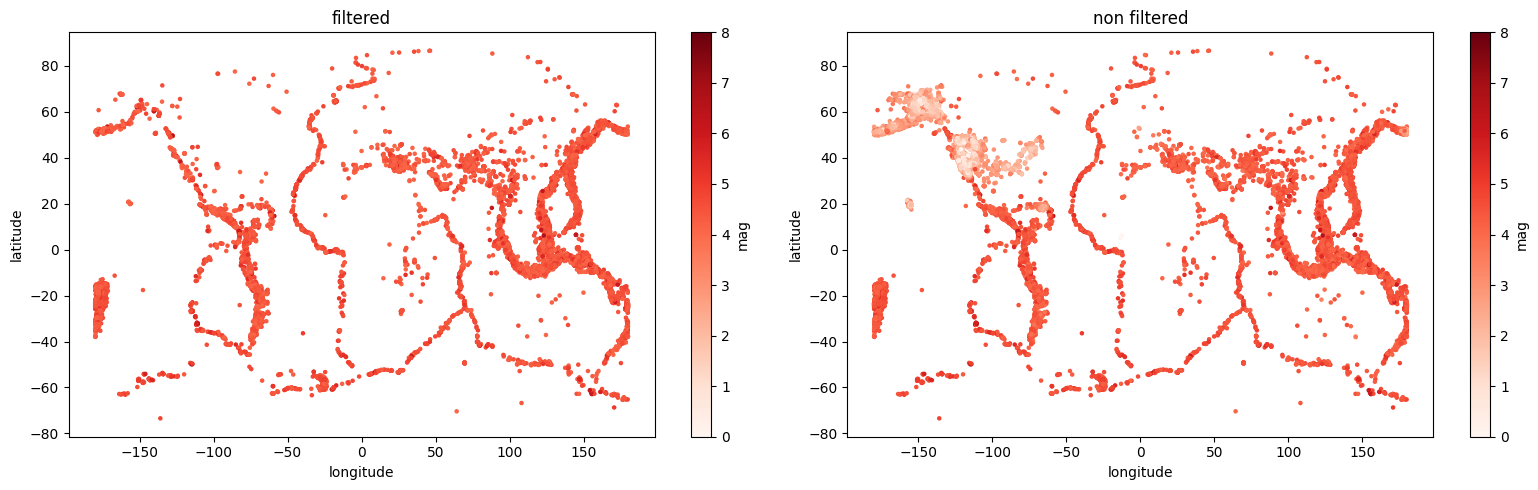

In [75]:
#plotting
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

df_mag4.plot(ax=ax[0], kind="scatter", x="longitude", y="latitude", s=5, c="mag", colormap="Reds", vmin=0, vmax=8)
ax[0].set_title("filtered")

df.plot(ax=ax[1], kind="scatter", x="longitude", y="latitude", s=5, c="mag", colormap="Reds", vmin=0, vmax=8)
ax[1].set_title("non filtered")

plt.tight_layout()
plt.show()

Do you notice a difference between the filtered and unfiltered datasets?